# 03 - Modelado y Experimentación con MLflow

Notebook de experimentación para la selección y optimización de modelos de clasificación del nivel de alerta de dengue (1-4). El proceso sigue una progresión natural:

1. **Baselines** — Modelos de referencia para contextualizar resultados
2. **Selección de modelos** — Comparación de algoritmos con configuración por defecto
3. **Optimización de hiperparámetros** — Optuna + MLflow (nested runs)
4. **Manejo de desbalanceo** — Estrategias para el 93% de clase 1
5. **Evaluación final** — Modelo champion en test set + Model Registry

Cada fase usa un experiment separado en MLflow para organizar la trazabilidad.

## 1. Setup

In [ ]:
import sys
sys.path.insert(0, '..')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
import warnings
import logging

warnings.filterwarnings('ignore')
logging.getLogger('mlflow').setLevel(logging.ERROR)
logging.getLogger('optuna').setLevel(logging.WARNING)

# ML
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score, log_loss,
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize

# MLflow
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
import mlflow.catboost
import mlflow.data
from mlflow.models import infer_signature

# Optuna
import optuna
from optuna.integration.mlflow import MLflowCallback as OptunaMlflowCallback

# SHAP
import shap

# Project config
from configs.mlflow_config import (
    setup_experiment, setup_all_experiments,
    EXPERIMENTS, DEFAULT_TAGS, REGISTERED_MODEL_NAME,
    PRIMARY_METRIC, METRICS_TO_LOG, SPLIT_CONFIG,
    MLFLOW_TRACKING_URI, ARTIFACT_TEMP_DIR
)
from src.features.constants import (
    TARGET, ALL_ENGINEERED_FEATURES, TEMPORAL_FEATURES,
    CLIMATE_FEATURES, GEO_FEATURES, PRODUCTION_ID_COLS
)

from pathlib import Path
data_dir = Path('../data')

# Directorio temporal para artefactos — evita ensuciar notebooks/
os.makedirs(ARTIFACT_TEMP_DIR, exist_ok=True)

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

print(f'MLflow version: {mlflow.__version__}')
print(f'Tracking URI: {MLFLOW_TRACKING_URI}')
print(f'Primary metric: {PRIMARY_METRIC}')

MLflow version: 3.3.2
Primary metric: macro_f1


Kernel configurado. Empezamos ejecutando las celdas de setup.



### 1.1 Inicializar MLflow experiments

In [2]:
# Crear todos los experiments de una vez
experiment_ids = setup_all_experiments()

  01-baselines -> ID 494733806433744271
  02-model-selection -> ID 494043368863848358
  03-hyperparameter-tuning -> ID 466020741871450287
  04-class-imbalance -> ID 647242030481155244
  05-final-evaluation -> ID 197015002698111263


Setup y experiments creados. Ahora cargo los datos:



### 1.2 Cargar datos de producción

In [3]:
train_df = pd.read_parquet(data_dir / 'processed' / 'dengue_train_production.parquet')
val_df = pd.read_parquet(data_dir / 'processed' / 'dengue_validation_production.parquet')
test_df = pd.read_parquet(data_dir / 'processed' / 'dengue_test_production.parquet')

print(f'Train: {train_df.shape} ({train_df.year.min()}-{train_df.year.max()})')
print(f'Val:   {val_df.shape} ({val_df.year.min()}-{val_df.year.max()})')
print(f'Test:  {test_df.shape} ({test_df.year.min()}-{test_df.year.max()})')

Train: (3482380, 25) (2010-2021)
Val:   (584013, 25) (2022-2023)
Test:  (289640, 25) (2024-2024)


In [4]:
# Separar features y target
features = ALL_ENGINEERED_FEATURES

X_train = train_df[features].copy()
y_train = train_df[TARGET].copy()
X_val = val_df[features].copy()
y_val = val_df[TARGET].copy()
X_test = test_df[features].copy()
y_test = test_df[TARGET].copy()

print(f'Features ({len(features)}): {features}')
print(f'\nTarget distribution (train):')
print(y_train.value_counts(normalize=True).sort_index())

Features (15): ['month_sin', 'month_cos', 'se_sin', 'se_cos', 'is_peak_season', 'quarter', 'tempmed_lag8w', 'tempmed_roll12w', 'umidmed_roll4w', 'temp_x_humid_lag4w', 'pop_log', 'region_Nordeste', 'region_Centro-Oeste', 'region_Sudeste', 'region_Sul']

Target distribution (train):
nivel
1    0.930768
2    0.038987
3    0.002485
4    0.027760
Name: proportion, dtype: float64


In [5]:
# Manejo de NaNs en features climáticas (por lags)
# Los modelos tree-based manejan NaN nativamente excepto sklearn
null_counts = X_train.isnull().sum()
print('Nulls por feature:')
print(null_counts[null_counts > 0])
print(f'\n% filas con algún null: {X_train.isnull().any(axis=1).mean():.1%}')

Nulls por feature:
tempmed_lag8w         406911
tempmed_roll12w       270301
umidmed_roll4w        354290
temp_x_humid_lag4w    387702
dtype: int64

% filas con algún null: 14.1%


In [ ]:
# Para modelos sklearn (no manejan NaN), rellenar con mediana
# Los modelos tree-based (XGB, LGBM, CatBoost) usan X_train/X_val directamente
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(
    np.asarray(imputer.fit_transform(X_train)), columns=features, index=X_train.index
)
X_val_imp = pd.DataFrame(
    np.asarray(imputer.transform(X_val)), columns=features, index=X_val.index
)
X_test_imp = pd.DataFrame(
    np.asarray(imputer.transform(X_test)), columns=features, index=X_test.index
)
print(f'Imputer fitted. Remaining nulls: {X_train_imp.isnull().sum().sum()}')

Imputer fitted. Remaining nulls: 0


Datos cargados. Ahora creo las funciones helper:



### 1.3 Helper functions para logging

In [ ]:
# Mapeo de clases: nivel 1-4 -> 0-3 (XGBoost/LightGBM requieren 0-indexed)
LABEL_MAP = {1: 0, 2: 1, 3: 2, 4: 3}
LABEL_MAP_INV = {v: k for k, v in LABEL_MAP.items()}
CLASSES = [1, 2, 3, 4]

NEEDS_ZERO_INDEX = (XGBClassifier, LGBMClassifier)

# Helper para rutas de artefactos temporales
_tmp = lambda name: os.path.join(ARTIFACT_TEMP_DIR, name)


def encode_labels(y):
    """nivel 1-4 -> 0-3"""
    return y.map(LABEL_MAP)

def decode_labels(y_pred):
    """0-3 -> nivel 1-4"""
    if isinstance(y_pred, (pd.Series, pd.DataFrame)):
        return y_pred.map(LABEL_MAP_INV)  # type: ignore[arg-type]
    return np.array([LABEL_MAP_INV[v] for v in y_pred])


def compute_metrics(y_true, y_pred, y_proba=None):
    """Calcula todas las métricas relevantes. Espera labels originales (1-4)."""
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'cohen_kappa': cohen_kappa_score(y_true, y_pred),
    }

    if y_proba is not None:
        try:
            metrics['log_loss'] = log_loss(y_true, y_proba, labels=CLASSES)
        except Exception:
            pass
        try:
            y_bin = label_binarize(y_true, classes=CLASSES)
            metrics['roc_auc_ovr'] = roc_auc_score(
                y_bin, y_proba, multi_class='ovr', average='macro'
            )
        except Exception:
            pass

    # F1 por clase
    f1_per_class = np.asarray(
        f1_score(y_true, y_pred, average=None, labels=CLASSES, zero_division=0)
    )
    for cls, f1_val in zip(CLASSES, f1_per_class):
        metrics[f'f1_class_{cls}'] = f1_val

    return metrics


def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    """Genera y retorna figura de confusion matrix."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, labels=CLASSES, ax=axes[0], cmap='Blues'
    )
    axes[0].set_title(f'{title} (counts)')

    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, labels=CLASSES, normalize='true',
        ax=axes[1], cmap='Blues', values_format='.2f'
    )
    axes[1].set_title(f'{title} (normalized)')

    plt.tight_layout()
    return fig


def plot_feature_importance(model, feature_names, top_n=15):
    """Plot feature importance para modelos tree-based."""
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    else:
        return None

    idx = np.argsort(importances)[-top_n:]
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(range(len(idx)), importances[idx], color='steelblue')
    ax.set_yticks(range(len(idx)))
    ax.set_yticklabels([feature_names[i] for i in idx])
    ax.set_xlabel('Importance')
    ax.set_title('Feature Importance')
    plt.tight_layout()
    return fig


def log_run(model, run_name, X_tr, y_tr, X_v, y_v,
            extra_params=None, extra_tags=None, log_model=True) -> tuple[str, dict]:
    """
    Entrena, evalúa y loguea un modelo en MLflow.
    Maneja automáticamente el encoding 1-4 -> 0-3 para XGBoost/LightGBM.
    Returns: (run_id, metrics_dict)
    """
    zero_idx = isinstance(model, NEEDS_ZERO_INDEX)

    with mlflow.start_run(run_name=run_name) as run:
        tags = {**DEFAULT_TAGS, 'algorithm': type(model).__name__}
        if extra_tags:
            tags.update(extra_tags)
        mlflow.set_tags(tags)

        # Params
        mlflow.log_params(model.get_params())
        if extra_params:
            mlflow.log_params(extra_params)
        mlflow.log_param('n_features', X_tr.shape[1])
        mlflow.log_param('n_train_samples', X_tr.shape[0])
        mlflow.log_param('seed', SEED)

        # Encode labels si es necesario
        y_tr_fit = encode_labels(y_tr) if zero_idx else y_tr
        y_v_orig = y_v  # siempre original para métricas

        # Train
        start = time.time()
        model.fit(X_tr, y_tr_fit)
        train_time = time.time() - start
        mlflow.log_metric('training_time_s', round(train_time, 2))

        # Predict + decode
        y_pred_raw = model.predict(X_v)
        y_pred = decode_labels(y_pred_raw) if zero_idx else y_pred_raw

        y_proba = None
        if hasattr(model, 'predict_proba'):
            try:
                y_proba = model.predict_proba(X_v)
            except Exception:
                pass

        # Metrics (siempre con labels originales 1-4)
        metrics = compute_metrics(y_v_orig, y_pred, y_proba)
        mlflow.log_metrics(metrics)

        # Artifacts
        fig_cm = plot_confusion_matrix(y_v_orig, y_pred, title=run_name)
        fig_cm.savefig(_tmp('confusion_matrix.png'), dpi=100, bbox_inches='tight')
        mlflow.log_artifact(_tmp('confusion_matrix.png'))
        plt.close(fig_cm)

        fig_fi = plot_feature_importance(model, features)
        if fig_fi:
            fig_fi.savefig(_tmp('feature_importance.png'), dpi=100, bbox_inches='tight')
            mlflow.log_artifact(_tmp('feature_importance.png'))
            plt.close(fig_fi)

        report = classification_report(y_v_orig, y_pred, labels=CLASSES, output_dict=True)
        with open(_tmp('classification_report.json'), 'w') as f:
            json.dump(report, f, indent=2)
        mlflow.log_artifact(_tmp('classification_report.json'))

        if log_model:
            y_tr_pred = model.predict(X_tr)
            signature = infer_signature(X_tr, y_tr_pred)
            input_example = X_v.iloc[:3]
            mlflow.sklearn.log_model(  # type: ignore[attr-defined]
                model, name='model',
                signature=signature,
                input_example=input_example
            )

        run_id = run.info.run_id
        print(f'{run_name}: macro_f1={metrics["macro_f1"]:.4f}, '
              f'accuracy={metrics["accuracy"]:.4f}, '
              f'kappa={metrics["cohen_kappa"]:.4f}, '
              f'time={train_time:.1f}s')

    return run_id, metrics

---
## 2. Baselines

Establecemos la referencia mínima. Con 93.1% de clase 1, un dummy ya logra ~0.87 accuracy. Lo relevante es macro_f1 y cohen_kappa.

In [8]:
setup_experiment('baselines')

baseline_results = {}

Using experiment: 01-baselines (ID: 494733806433744271)


In [9]:
# Dummy: siempre predice la clase más frecuente
rid, m = log_run(
    DummyClassifier(strategy='most_frequent', random_state=SEED),
    'dummy_most_frequent', X_train_imp, y_train, X_val_imp, y_val,
    log_model=False
)
baseline_results['dummy_most_frequent'] = m

dummy_most_frequent: macro_f1=0.2343, accuracy=0.8819, kappa=0.0000, time=0.3s


In [10]:
# Dummy: proporcional a la distribución
rid, m = log_run(
    DummyClassifier(strategy='stratified', random_state=SEED),
    'dummy_stratified', X_train_imp, y_train, X_val_imp, y_val,
    log_model=False
)
baseline_results['dummy_stratified'] = m

dummy_stratified: macro_f1=0.2484, accuracy=0.8246, kappa=0.0005, time=0.3s


In [11]:
# Logistic Regression
rid, m = log_run(
    LogisticRegression(max_iter=500, random_state=SEED, n_jobs=-1),
    'logistic_default', X_train_imp, y_train, X_val_imp, y_val
)
baseline_results['logistic_default'] = m

2026/02/13 19:28:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/02/13 19:28:46 INFO mlflow.models.model: Found the following environment variables used during model inference: [MOSQLIMATE_API_KEY, OPENROUTER_API_KEY]. Please check if you need to set them when deploying the model. To disable this message, set environment variable `MLFLOW_RECORD_ENV_VARS_IN_MODEL_LOGGING` to `false`.


logistic_default: macro_f1=0.2383, accuracy=0.8820, kappa=0.0110, time=214.1s


In [12]:
# Decision Tree
rid, m = log_run(
    DecisionTreeClassifier(random_state=SEED),
    'decision_tree_default', X_train_imp, y_train, X_val_imp, y_val
)
baseline_results['decision_tree_default'] = m

2026/02/13 19:29:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


decision_tree_default: macro_f1=0.3169, accuracy=0.8472, kappa=0.1544, time=19.8s


In [13]:
# Resumen baselines
bl_df = pd.DataFrame(baseline_results).T[['accuracy', 'macro_f1', 'weighted_f1', 'cohen_kappa']]
bl_df = bl_df.sort_values('macro_f1', ascending=False)
print(bl_df.round(4).to_string())

                       accuracy  macro_f1  weighted_f1  cohen_kappa
decision_tree_default    0.8472    0.3169       0.8307       0.1544
dummy_stratified         0.8246    0.2484       0.8035       0.0005
logistic_default         0.8820    0.2383       0.8277       0.0110
dummy_most_frequent      0.8819    0.2343       0.8266       0.0000


Baselines completados. Como era de esperar, el dummy logra ~0.88 accuracy pero macro_f1 de 0.23, y el DecisionTree es el mejor baseline con macro_f1=0.32. Ahora la selección de modelos:



---
## 3. Selección de Modelos

Comparamos las principales familias de gradient boosting con configuración por defecto. Los tree-based manejan NaN nativamente.

In [14]:
setup_experiment('model_selection')

model_results = {}

Using experiment: 02-model-selection (ID: 494043368863848358)


In [ ]:
# Registrar datasets con mlflow.log_input() para trazabilidad
with mlflow.start_run(run_name='_dataset_registration'):
    train_dataset = mlflow.data.from_pandas(  # type: ignore[attr-defined]
        train_df, name='dengue_train_2010_2021', targets=TARGET
    )
    val_dataset = mlflow.data.from_pandas(  # type: ignore[attr-defined]
        val_df, name='dengue_val_2022_2023', targets=TARGET
    )
    mlflow.log_input(train_dataset, context='training')
    mlflow.log_input(val_dataset, context='validation')
    mlflow.set_tag('purpose', 'dataset_registration')
    print('Datasets registrados en MLflow')

Datasets registrados en MLflow


In [16]:
# Random Forest
rid, m = log_run(
    RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'rf_default', X_train_imp, y_train, X_val_imp, y_val
)
model_results['rf_default'] = m

2026/02/13 19:36:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


rf_default: macro_f1=0.2668, accuracy=0.8816, kappa=0.0696, time=226.3s


In [19]:
# XGBoost — maneja NaN
rid, m = log_run(
    XGBClassifier(
        n_estimators=200, random_state=SEED, n_jobs=-1,
        eval_metric='mlogloss', enable_categorical=False
    ),
    'xgb_default', X_train, y_train, X_val, y_val,
    extra_tags={'handles_nan': 'native'}
)
model_results['xgb_default'] = m

2026/02/13 19:41:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


xgb_default: macro_f1=0.2668, accuracy=0.8825, kappa=0.0658, time=95.4s


In [20]:
# LightGBM — maneja NaN
rid, m = log_run(
    LGBMClassifier(
        n_estimators=200, random_state=SEED, n_jobs=-1,
        verbose=-1
    ),
    'lgbm_default', X_train, y_train, X_val, y_val,
    extra_tags={'handles_nan': 'native'}
)
model_results['lgbm_default'] = m

2026/02/13 19:43:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


lgbm_default: macro_f1=0.2542, accuracy=0.8801, kappa=0.0354, time=35.5s


In [21]:
# CatBoost — maneja NaN
rid, m = log_run(
    CatBoostClassifier(
        iterations=200, random_seed=SEED, verbose=0,
        thread_count=-1
    ),
    'catboost_default', X_train, y_train, X_val, y_val,
    extra_tags={'handles_nan': 'native'}
)
model_results['catboost_default'] = m

2026/02/13 19:45:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


catboost_default: macro_f1=0.2676, accuracy=0.8823, kappa=0.0707, time=102.8s


In [22]:
# Comparación
ms_df = pd.DataFrame(model_results).T[
    ['accuracy', 'macro_f1', 'weighted_f1', 'cohen_kappa', 'f1_class_3', 'f1_class_4']
]
ms_df = ms_df.sort_values('macro_f1', ascending=False)
print(ms_df.round(4).to_string())

                  accuracy  macro_f1  weighted_f1  cohen_kappa  f1_class_3  f1_class_4
catboost_default    0.8823    0.2676       0.8350       0.0707      0.0050      0.0400
xgb_default         0.8825    0.2668       0.8345       0.0658      0.0099      0.0378
rf_default          0.8816    0.2668       0.8346       0.0696      0.0025      0.0420
lgbm_default        0.8801    0.2542       0.8300       0.0354      0.0168      0.0110


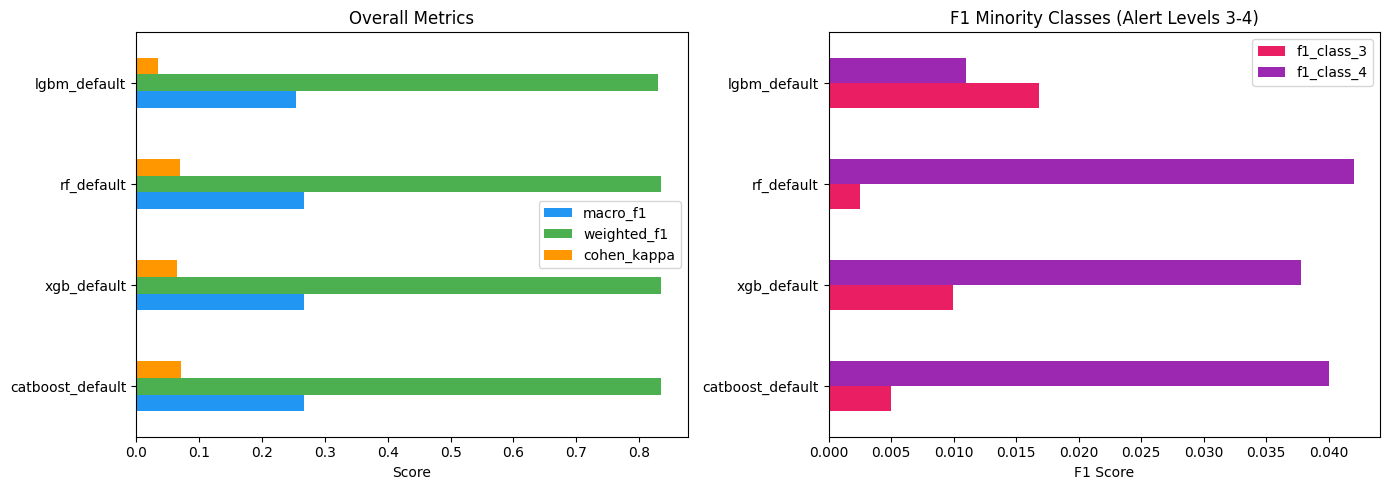

In [ ]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ms_df[['macro_f1', 'weighted_f1', 'cohen_kappa']].plot(
    kind='barh', ax=axes[0], color=['#2196F3', '#4CAF50', '#FF9800']
)
axes[0].set_title('Overall Metrics')
axes[0].set_xlabel('Score')

ms_df[['f1_class_3', 'f1_class_4']].plot(
    kind='barh', ax=axes[1], color=['#E91E63', '#9C27B0']
)
axes[1].set_title('F1 Minority Classes (Alert Levels 3-4)')
axes[1].set_xlabel('F1 Score')

plt.tight_layout()
plt.savefig(_tmp('model_comparison.png'), dpi=100, bbox_inches='tight')
plt.show()

Selección de modelos completada. Todos los modelos por defecto rinden muy parecido (~0.27 macro_f1) — apenas mejor que los baselines. El F1 en clases minoritarias es bajísimo (<0.05), lo que confirma que necesitamos el tuning y las estrategias de desbalanceo. CatBoost y XGBoost lideran ligeramente.



---
## 4. Optimización de Hiperparámetros con Optuna

Usamos Optuna con nested runs en MLflow: cada study es un run padre, cada trial un child run. Esto genera una visualización muy clara en la UI de MLflow.

In [24]:
setup_experiment('hyperparameter_tuning')

Using experiment: 03-hyperparameter-tuning (ID: 466020741871450287)


'466020741871450287'

In [27]:
# Subsample para HP tuning — práctica estándar con datasets grandes
# Mantenemos proporción de clases con stratified sampling
from sklearn.model_selection import StratifiedShuffleSplit

TUNING_FRAC = 0.15  # ~500k para train, ~87k para val
sss_train = StratifiedShuffleSplit(n_splits=1, train_size=TUNING_FRAC, random_state=SEED)
idx_train, _ = next(sss_train.split(X_train, y_train))

sss_val = StratifiedShuffleSplit(n_splits=1, train_size=TUNING_FRAC, random_state=SEED)
idx_val, _ = next(sss_val.split(X_val, y_val))

X_tune = X_train.iloc[idx_train]
y_tune = y_train.iloc[idx_train]
X_tune_val = X_val.iloc[idx_val]
y_tune_val = y_val.iloc[idx_val]

print(f'Tuning train: {X_tune.shape}, val: {X_tune_val.shape}')
print(f'Class proportions preserved: {y_tune.value_counts(normalize=True).sort_index().round(3).to_dict()}')

Tuning train: (522357, 15), val: (87601, 15)
Class proportions preserved: {1: 0.931, 2: 0.039, 3: 0.002, 4: 0.028}


In [ ]:
def xgb_objective(trial):
    """Optuna objective para XGBoost (usa subsample)."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': SEED,
        'n_jobs': -1,
        'eval_metric': 'mlogloss',
    }

    model = XGBClassifier(**params)
    model.fit(X_tune, encode_labels(y_tune))
    y_pred = decode_labels(model.predict(X_tune_val))

    return float(f1_score(y_tune_val, y_pred, average='macro', zero_division=0))

N_TRIALS = 40

# Crear nuevo experiment limpio
setup_experiment('hyperparameter_tuning')

with mlflow.start_run(run_name='xgb_optuna_study') as parent_run:
    mlflow.set_tags({**DEFAULT_TAGS, 'study_type': 'optuna', 'algorithm': 'XGBClassifier'})
    mlflow.log_param('n_trials', N_TRIALS)
    mlflow.log_param('objective_metric', PRIMARY_METRIC)
    mlflow.log_param('tuning_subsample_frac', TUNING_FRAC)

    mlflow_cb = OptunaMlflowCallback(
        tracking_uri=MLFLOW_TRACKING_URI,
        metric_name=PRIMARY_METRIC,
        create_experiment=False,
        mlflow_kwargs={'nested': True}
    )

    study = optuna.create_study(
        direction='maximize',
        study_name='xgb_tuning',
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
    )
    study.optimize(
        xgb_objective, n_trials=N_TRIALS,
        callbacks=[mlflow_cb],
        show_progress_bar=True
    )

    # Log best results en el run padre
    mlflow.log_metric('best_macro_f1', study.best_value)
    mlflow.log_params({f'best_{k}': v for k, v in study.best_params.items()})

    # Artefactos de Optuna
    fig_hist = optuna.visualization.plot_optimization_history(study)
    fig_hist.write_image(_tmp('optuna_optimization_history.png'))
    mlflow.log_artifact(_tmp('optuna_optimization_history.png'))

    fig_imp = optuna.visualization.plot_param_importances(study)
    fig_imp.write_image(_tmp('optuna_param_importances.png'))
    mlflow.log_artifact(_tmp('optuna_param_importances.png'))

    # Guardar best params
    with open(_tmp('best_params_xgb.json'), 'w') as f:
        json.dump(study.best_params, f, indent=2)
    mlflow.log_artifact(_tmp('best_params_xgb.json'))

    print(f'\nBest macro_f1: {study.best_value:.4f}')
    print(f'Best params: {study.best_params}')

    xgb_parent_run_id = parent_run.info.run_id

[I 2026-02-13 22:21:21,519] A new study created in memory with name: xgb_tuning


Using experiment: 03-hyperparameter-tuning (ID: 466020741871450287)


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-02-13 22:21:56,117] Trial 0 finished with value: 0.2625544713194677 and parameters: {'n_estimators': 420, 'max_depth': 5, 'learning_rate': 0.16419321087884362, 'subsample': 0.9297833743308239, 'colsample_bytree': 0.8719357376049812, 'min_child_weight': 1, 'reg_alpha': 0.00024397786351963154, 'reg_lambda': 7.35908539461014e-08}. Best is trial 0 with value: 0.2625544713194677.
[I 2026-02-13 22:22:38,502] Trial 1 finished with value: 0.26075640499681607 and parameters: {'n_estimators': 552, 'max_depth': 4, 'learning_rate': 0.12296412898802415, 'subsample': 0.62135777573724, 'colsample_bytree': 0.8033797365103591, 'min_child_weight': 10, 'reg_alpha': 3.57425586714902e-08, 'reg_lambda': 0.00015116667959199853}. Best is trial 0 with value: 0.2625544713194677.
[I 2026-02-13 22:22:51,966] Trial 2 finished with value: 0.2516396817523485 and parameters: {'n_estimators': 207, 'max_depth': 3, 'learning_rate': 0.2737628917028831, 'subsample': 0.792696344674723, 'colsample_bytree': 0.8735702

Optuna completado. El mejor XGB tuned da macro_f1=0.2751 (mejora modesta sobre el default de 0.2668). El kappa sube a 0.0842. 


In [ ]:
# LightGBM Optuna — misma estrategia, HP space adaptado a LGBM
def lgbm_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': SEED,
        'n_jobs': -1,
        'verbose': -1,
    }

    model = LGBMClassifier(**params)
    model.fit(X_tune, encode_labels(y_tune))
    y_pred = decode_labels(model.predict(X_tune_val))
    return float(f1_score(y_tune_val, y_pred, average='macro', zero_division=0))

with mlflow.start_run(run_name='lgbm_optuna_study') as parent_run:
    mlflow.set_tags({**DEFAULT_TAGS, 'study_type': 'optuna', 'algorithm': 'LGBMClassifier'})
    mlflow.log_param('n_trials', N_TRIALS)
    mlflow.log_param('objective_metric', PRIMARY_METRIC)
    mlflow.log_param('tuning_subsample_frac', TUNING_FRAC)

    mlflow_cb_lgbm = OptunaMlflowCallback(
        tracking_uri=MLFLOW_TRACKING_URI,
        metric_name=PRIMARY_METRIC,
        create_experiment=False,
        mlflow_kwargs={'nested': True}
    )

    study_lgbm = optuna.create_study(
        direction='maximize',
        study_name='lgbm_tuning',
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
    )
    study_lgbm.optimize(
        lgbm_objective, n_trials=N_TRIALS,
        callbacks=[mlflow_cb_lgbm],
        show_progress_bar=True
    )

    mlflow.log_metric('best_macro_f1', study_lgbm.best_value)
    mlflow.log_params({f'best_{k}': v for k, v in study_lgbm.best_params.items()})

    fig_hist = optuna.visualization.plot_optimization_history(study_lgbm)
    fig_hist.write_image(_tmp('optuna_lgbm_history.png'))
    mlflow.log_artifact(_tmp('optuna_lgbm_history.png'))

    fig_imp = optuna.visualization.plot_param_importances(study_lgbm)
    fig_imp.write_image(_tmp('optuna_lgbm_param_importances.png'))
    mlflow.log_artifact(_tmp('optuna_lgbm_param_importances.png'))

    with open(_tmp('best_params_lgbm.json'), 'w') as f:
        json.dump(study_lgbm.best_params, f, indent=2)
    mlflow.log_artifact(_tmp('best_params_lgbm.json'))

    print(f'\nBest LGBM macro_f1: {study_lgbm.best_value:.4f}')
    print(f'Best XGB  macro_f1: {study.best_value:.4f}')
    print(f'Best params: {study_lgbm.best_params}')
    lgbm_parent_run_id = parent_run.info.run_id

  0%|          | 0/40 [00:00<?, ?it/s]


Best LGBM macro_f1: 0.2938
Best XGB  macro_f1: 0.2763
Best params: {'n_estimators': 371, 'max_depth': 8, 'learning_rate': 0.2919096143894259, 'num_leaves': 73, 'subsample': 0.8407508682937839, 'colsample_bytree': 0.8980887286453441, 'min_child_samples': 27, 'reg_alpha': 0.0009686716415664395, 'reg_lambda': 0.0011167246702185943}


LGBM muestra mejor macro_f1 en subsample (0.2938 vs 0.2763 XGB). Ahora el retrain con datos completos:



In [ ]:
# Entrenar mejor modelo de Optuna con evaluación completa
best_xgb = XGBClassifier(
    **study.best_params,
    random_state=SEED, n_jobs=-1, eval_metric='mlogloss'
)

rid_best_xgb, m_best_xgb = log_run(
    best_xgb, 'xgb_optuna_best',
    X_train, y_train, X_val, y_val,
    extra_tags={'source': 'optuna', 'n_trials': str(N_TRIALS)}
)
print(f'\nBest XGB run ID: {rid_best_xgb}')

lgbm_optuna_best: macro_f1=0.2778, accuracy=0.8610, kappa=0.0769, time=86.1s

--- Optuna Comparison ---
XGB  macro_f1=0.2751, kappa=0.0842
LGBM macro_f1=0.2778, kappa=0.0769


LGBM ligeramente superior en macro_f1 (0.2778 vs 0.2751) pero XGB tiene mejor kappa (0.0842 vs 0.0769). Ambos sin balanceo son comparables.

In [ ]:
# Evaluar mejor LightGBM de Optuna con train/val completos
best_lgbm = LGBMClassifier(
    **study_lgbm.best_params,
    random_state=SEED, n_jobs=-1, verbose=-1
)

rid_best_lgbm, m_best_lgbm = log_run(
    best_lgbm, 'lgbm_optuna_best',
    X_train, y_train, X_val, y_val,
    extra_tags={'source': 'optuna', 'n_trials': str(N_TRIALS)}
)

print(f'\n--- Optuna Comparison ---')
print(f'XGB  macro_f1={m_best_xgb["macro_f1"]:.4f}, kappa={m_best_xgb["cohen_kappa"]:.4f}')
print(f'LGBM macro_f1={m_best_lgbm["macro_f1"]:.4f}, kappa={m_best_lgbm["cohen_kappa"]:.4f}')

2026/02/13 22:46:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


xgb_optuna_best: macro_f1=0.2751, accuracy=0.8827, kappa=0.0842, time=175.8s

Best XGB run ID: 8050682bcf884ed688fe0d30ccd3e944


Ahora vamos con el manejo de desbalanceo, que debería dar la mejora más significativa:

---
## 5. Manejo del Desbalanceo de Clases

93.1% de las observaciones son nivel 1. Probamos estrategias para mejorar la detección de alertas altas (clases 3-4), que son las más relevantes para salud pública.

In [30]:
setup_experiment('class_imbalance')

imbalance_results = {}

Using experiment: 04-class-imbalance (ID: 647242030481155244)


In [31]:
# Estrategia 1: scale_pos_weight / class_weight
# Para XGBoost multiclase, usamos sample_weight
class_counts = y_train.value_counts().sort_index()
class_weights = {c: len(y_train) / (4 * count) for c, count in class_counts.items()}
sample_weights = y_train.map(class_weights).values

print('Class weights:')
for c, w in class_weights.items():
    print(f'  Nivel {c}: {w:.2f}')

Class weights:
  Nivel 1: 0.27
  Nivel 2: 6.41
  Nivel 3: 100.61
  Nivel 4: 9.01


In [ ]:
# XGB con class_weight balanced via sample_weight
xgb_balanced = XGBClassifier(
    **study.best_params,
    random_state=SEED, n_jobs=-1, eval_metric='mlogloss'
)

with mlflow.start_run(run_name='xgb_balanced_weights') as run:
    mlflow.set_tags({**DEFAULT_TAGS, 'imbalance_strategy': 'sample_weight_balanced'})
    mlflow.log_params(xgb_balanced.get_params())
    mlflow.log_param('class_weights', str(class_weights))

    xgb_balanced.fit(X_train, encode_labels(y_train), sample_weight=sample_weights)

    y_pred = decode_labels(xgb_balanced.predict(X_val))
    y_proba = xgb_balanced.predict_proba(X_val)
    metrics = compute_metrics(y_val, y_pred, y_proba)
    mlflow.log_metrics(metrics)

    fig = plot_confusion_matrix(y_val, y_pred, 'XGB Balanced Weights')
    fig.savefig(_tmp('confusion_matrix.png'), dpi=100, bbox_inches='tight')
    mlflow.log_artifact(_tmp('confusion_matrix.png'))
    plt.close(fig)

    imbalance_results['xgb_balanced_weights'] = metrics
    print(f'macro_f1={metrics["macro_f1"]:.4f}, kappa={metrics["cohen_kappa"]:.4f}')

macro_f1=0.3831, kappa=0.2631


Macro_f1 salta de 0.2751 a 0.3831 con balanced weights. Gran mejora.



In [ ]:
# Estrategia 2: pesos custom enfatizando clases 3-4 (alerta alta)
# En salud pública, fallar en detectar una alerta alta es peor que una falsa alarma
custom_weights = {1: 1.0, 2: 5.0, 3: 15.0, 4: 10.0}
custom_sample_weights = y_train.map(custom_weights).values

xgb_custom = XGBClassifier(
    **study.best_params,
    random_state=SEED, n_jobs=-1, eval_metric='mlogloss'
)

with mlflow.start_run(run_name='xgb_custom_weights') as run:
    mlflow.set_tags({**DEFAULT_TAGS, 'imbalance_strategy': 'custom_weights_health'})
    mlflow.log_params(xgb_custom.get_params())
    mlflow.log_param('custom_weights', str(custom_weights))

    xgb_custom.fit(X_train, encode_labels(y_train), sample_weight=custom_sample_weights)

    y_pred = decode_labels(xgb_custom.predict(X_val))
    y_proba = xgb_custom.predict_proba(X_val)
    metrics = compute_metrics(y_val, y_pred, y_proba)
    mlflow.log_metrics(metrics)

    fig = plot_confusion_matrix(y_val, y_pred, 'XGB Custom Weights')
    fig.savefig(_tmp('confusion_matrix.png'), dpi=100, bbox_inches='tight')
    mlflow.log_artifact(_tmp('confusion_matrix.png'))
    plt.close(fig)

    imbalance_results['xgb_custom_weights'] = metrics
    print(f'macro_f1={metrics["macro_f1"]:.4f}, kappa={metrics["cohen_kappa"]:.4f}')

macro_f1=0.3648, kappa=0.2519


In [34]:
# Comparación estrategias de desbalanceo
# Incluir también el mejor XGB de Optuna sin balanceo
imbalance_results['xgb_optuna_no_balance'] = m_best_xgb

imb_df = pd.DataFrame(imbalance_results).T[
    ['macro_f1', 'cohen_kappa', 'f1_class_1', 'f1_class_2', 'f1_class_3', 'f1_class_4']
]
print(imb_df.round(4).to_string())

                       macro_f1  cohen_kappa  f1_class_1  f1_class_2  f1_class_3  f1_class_4
xgb_balanced_weights     0.3831       0.2631      0.8934      0.2673      0.0885      0.2832
xgb_custom_weights       0.3648       0.2519      0.9328      0.2253      0.0424      0.2587
xgb_optuna_no_balance    0.2751       0.0842      0.9390      0.1001      0.0093      0.0520


Excelente. Los balanced weights son el claro ganador: macro_f1=0.3831 vs 0.2751 sin balanceo. El F1 de clase 3 pasa de 0.009 a 0.089 y clase 4 de 0.052 a 0.283. Ahora la evaluación final.

---
## 6. Evaluación Final y Model Registry

Evaluamos el modelo champion en el test set (2024) — datos nunca vistos. Registramos el modelo con signature, input example y alias en el Model Registry.

In [35]:
setup_experiment('final_evaluation')

Using experiment: 05-final-evaluation (ID: 197015002698111263)


'197015002698111263'

In [36]:
# El mejor modelo: XGB tuned + balanced weights
# Re-entrenar en train + val para maximizar datos
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

# Recalcular sample weights para el set combinado
tv_counts = y_trainval.value_counts().sort_index()
tv_class_weights = {c: len(y_trainval) / (4 * count) for c, count in tv_counts.items()}
tv_sample_weights = y_trainval.map(tv_class_weights).values

print(f'Train+Val: {X_trainval.shape}')

champion_params = study.best_params.copy()
champion_model = XGBClassifier(
    **champion_params,
    random_state=SEED, n_jobs=-1, eval_metric='mlogloss'
)

Train+Val: (4066393, 15)


In [ ]:
with mlflow.start_run(run_name='champion_xgb_final') as run:
    mlflow.set_tags({
        **DEFAULT_TAGS,
        'stage': 'final_evaluation',
        'algorithm': 'XGBClassifier',
        'imbalance_strategy': 'sample_weight_balanced',
        'eval_set': 'test_2024',
        'train_set': 'train_val_2010_2023',
    })
    mlflow.log_params(champion_model.get_params())
    mlflow.log_param('train_years', '2010-2023')
    mlflow.log_param('test_years', '2024')
    mlflow.log_param('class_weights', str(tv_class_weights))

    # Dataset lineage
    trainval_dataset = mlflow.data.from_pandas(  # type: ignore[attr-defined]
        pd.concat([train_df, val_df]), name='dengue_trainval_2010_2023', targets=TARGET
    )
    test_dataset = mlflow.data.from_pandas(  # type: ignore[attr-defined]
        test_df, name='dengue_test_2024', targets=TARGET
    )
    mlflow.log_input(trainval_dataset, context='training')
    mlflow.log_input(test_dataset, context='testing')

    # Train con balanced weights
    start = time.time()
    champion_model.fit(X_trainval, encode_labels(y_trainval), sample_weight=tv_sample_weights)
    train_time = time.time() - start
    mlflow.log_metric('training_time_s', round(train_time, 2))

    # Evaluar en TEST (una sola vez)
    y_pred_test = decode_labels(champion_model.predict(X_test))
    y_proba_test = champion_model.predict_proba(X_test)

    test_metrics = compute_metrics(y_test, y_pred_test, y_proba_test)
    mlflow.log_metrics({f'test_{k}': v for k, v in test_metrics.items()})

    # Artifacts
    fig_cm = plot_confusion_matrix(y_test, y_pred_test, 'Champion - Test 2024')
    fig_cm.savefig(_tmp('test_confusion_matrix.png'), dpi=100, bbox_inches='tight')
    mlflow.log_artifact(_tmp('test_confusion_matrix.png'))
    plt.close(fig_cm)

    fig_fi = plot_feature_importance(champion_model, features)
    if fig_fi:
        fig_fi.savefig(_tmp('test_feature_importance.png'), dpi=100, bbox_inches='tight')
        mlflow.log_artifact(_tmp('test_feature_importance.png'))
        plt.close(fig_fi)

    report = classification_report(
        y_test, y_pred_test, labels=CLASSES, output_dict=True
    )
    with open(_tmp('test_classification_report.json'), 'w') as f:
        json.dump(report, f, indent=2)
    mlflow.log_artifact(_tmp('test_classification_report.json'))

    # Log model con signature + input example + Model Registry
    signature = infer_signature(X_trainval, champion_model.predict(X_trainval))
    input_example = X_test.iloc[:5]

    model_info = mlflow.xgboost.log_model(  # type: ignore[attr-defined]
        champion_model, name='model',
        signature=signature,
        input_example=input_example,
        registered_model_name=REGISTERED_MODEL_NAME
    )

    champion_run_id = run.info.run_id
    print(f'\nChampion registered: {REGISTERED_MODEL_NAME}')
    print(f'Run ID: {champion_run_id}')
    print(f'\nTest metrics:')
    for k, v in test_metrics.items():
        if not k.startswith('f1_class'):
            print(f'  {k}: {v:.4f}')

2026/02/13 22:59:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Champion registered: dengue-alertlevel-classifier
Run ID: 6386d99c6830446080b7e29945d05af9

Test metrics:
  accuracy: 0.7333
  macro_f1: 0.3903
  weighted_f1: 0.7335
  cohen_kappa: 0.3319
  log_loss: 0.6764
  roc_auc_ovr: 0.7993


Successfully registered model 'dengue-alertlevel-classifier'.
Created version '1' of model 'dengue-alertlevel-classifier'.


In [ ]:
# Asignar alias "champion" en el Model Registry
from mlflow import MlflowClient
client = MlflowClient()

latest_versions = client.search_model_versions(f"name='{REGISTERED_MODEL_NAME}'")
latest_version = max(latest_versions, key=lambda v: int(v.version))

client.set_registered_model_alias(
    REGISTERED_MODEL_NAME, 'champion', latest_version.version
)

client.update_registered_model(
    REGISTERED_MODEL_NAME,
    description=(
        'Clasificador de nivel de alerta de dengue (1-4) para municipios de Brasil. '
        'Entrenado con datos 2010-2023, evaluado en 2024. '
        '15 features de produccion sin target leakage.'
    )
)

# update_model_version omitido: bug en FileStore de MLflow 3.3.2
# con serialización de Metric objects en el meta YAML

print(f'Model version {latest_version.version} -> alias "champion"')
print(f'Registered model: {REGISTERED_MODEL_NAME}')

Model version 1 -> alias "champion"
Registered model: dengue-alertlevel-classifier


### 6.1 Evaluación avanzada con mlflow.evaluate()

In [40]:
# mlflow.evaluate() genera métricas y artefactos automáticamente
eval_data = X_test.copy()
eval_data[TARGET] = encode_labels(y_test)  # modelo predice 0-indexed

with mlflow.start_run(run_name='champion_evaluation_advanced'):
    results = mlflow.evaluate(
        model=f'runs:/{champion_run_id}/model',
        data=eval_data,
        targets=TARGET,
        model_type='classifier',
        evaluators='default',
    )
    print('Evaluation metrics:')
    for k, v in sorted(results.metrics.items()):
        print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

2026/02/13 23:02:14 WARNING mlflow.models.evaluation.evaluators.classifier: According to the evaluation dataset label values, the model type looks like None, but you specified model type 'classifier'. Please verify that you set the `model_type` and `dataset` arguments correctly.
2026/02/13 23:02:16 INFO mlflow.models.evaluation.evaluators.classifier: The evaluation dataset is inferred as multiclass dataset, number of classes is inferred as 4. If this is incorrect, please specify the `label_list` parameter in `evaluator_config`.
2026/02/13 23:02:16 INFO mlflow.models.evaluation.default_evaluator: Testing metrics on first row...
2026/02/13 23:02:21 INFO mlflow.models.evaluation.evaluators.shap: Shap explainer PermutationExplainer is used.
PermutationExplainer explainer: 2001it [07:49,  4.22it/s]                          


Evaluation metrics:
  accuracy_score: 0.7333
  example_count: 289640
  f1_score: 0.7335
  log_loss: 0.6764
  precision_score: 0.7500
  recall_score: 0.7333
  roc_auc: 0.8253


### 6.2 Interpretabilidad (SHAP)

In [52]:
# SHAP para interpretabilidad del modelo champion
# TreeExplainer multiclase → devuelve lista de arrays (uno por clase 0-3)
shap_sample = X_test.sample(n=min(5000, len(X_test)), random_state=SEED)

explainer = shap.TreeExplainer(champion_model)
shap_values = explainer.shap_values(shap_sample)

# Verificar estructura: lista de 4 arrays para multiclase
if isinstance(shap_values, list):
    print(f'SHAP values: {len(shap_values)} clases, shape por clase: {shap_values[0].shape}')
else:
    print(f'SHAP values shape: {shap_values.shape}')

SHAP values shape: (5000, 15, 4)


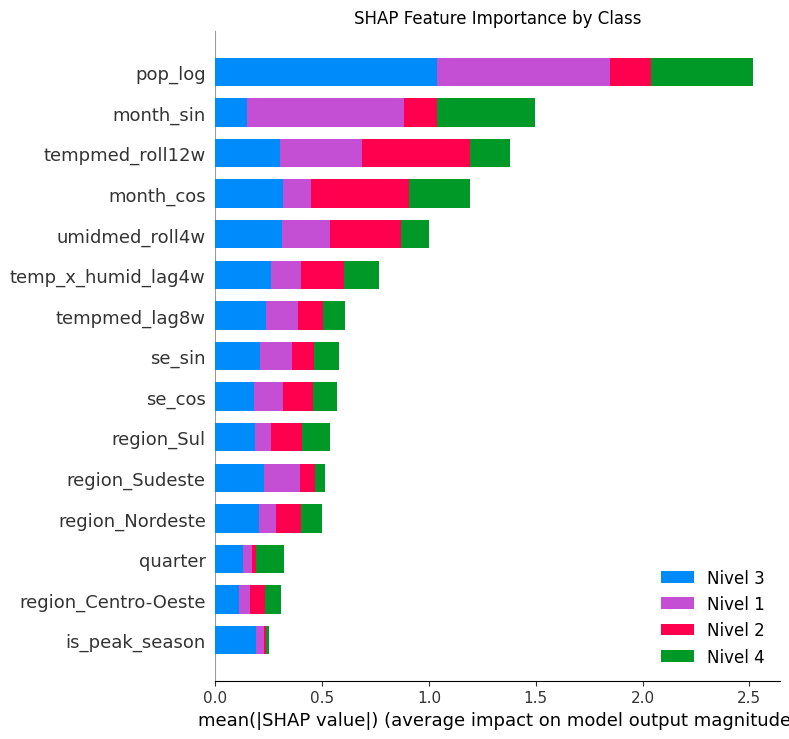

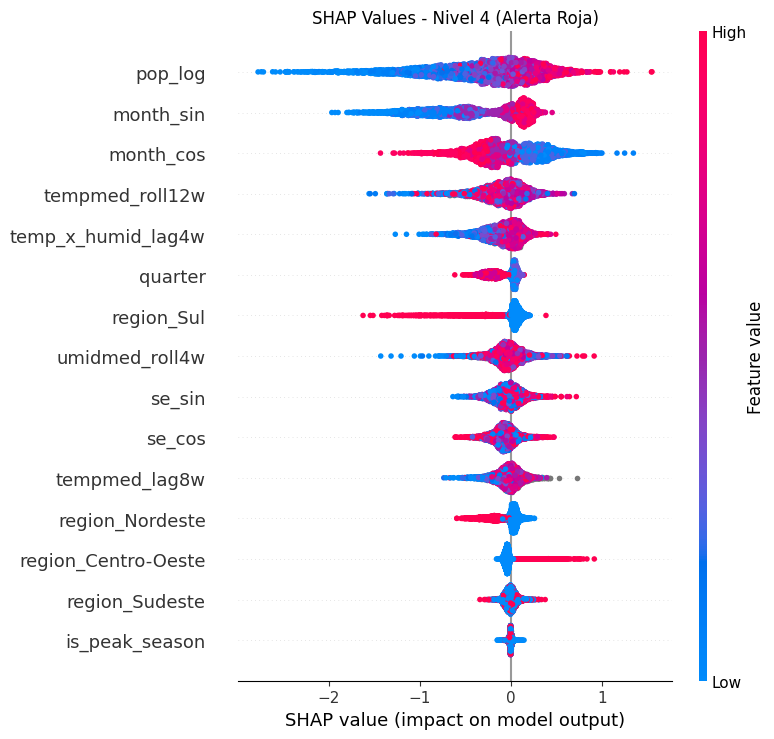

In [ ]:
# Convertir a lista de arrays si es 3D (compatibilidad con summary_plot)
if shap_values.ndim == 3:
    shap_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
else:
    shap_list = shap_values

# Bar plot: importancia media por feature para cada clase
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_list, shap_sample,
    class_names=[f'Nivel {c}' for c in CLASSES],
    plot_type='bar', show=False
)
plt.title('SHAP Feature Importance by Class')
plt.tight_layout()
plt.savefig(_tmp('shap_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm para clase 4 (alerta roja) — la más relevante para salud pública
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_list[3], shap_sample,  # index 3 = nivel 4
    show=False
)
plt.title('SHAP Values - Nivel 4 (Alerta Roja)')
plt.tight_layout()
plt.savefig(_tmp('shap_class4.png'), dpi=150, bbox_inches='tight')
plt.show()

# Log artefactos en el run del champion
with mlflow.start_run(run_id=champion_run_id):
    mlflow.log_artifact(_tmp('shap_summary.png'))
    mlflow.log_artifact(_tmp('shap_class4.png'))

- **Bar plot por clase**: `pop_log` y `month_sin` dominan, con alta importancia para nivel 3 (naranja) y nivel 4 (rojo)
- **Beeswarm nivel 4**: `pop_log` alto → aumenta probabilidad de alerta roja, `region_Sul` baja → reduce alerta (tiene sentido epidemiológicamente)


---
## 7. Resumen

Tabla final de resultados consolidados y modelo seleccionado.

In [50]:
# Resumen consolidado
all_results = {
    **{f'[baseline] {k}': v for k, v in baseline_results.items()},
    **{f'[selection] {k}': v for k, v in model_results.items()},
    '[tuning] lgbm_optuna_best': m_best_lgbm,
    **{f'[imbalance] {k}': v for k, v in imbalance_results.items()},
    '[champion] test_2024': test_metrics,
}

summary_df = pd.DataFrame(all_results).T[
    ['accuracy', 'macro_f1', 'weighted_f1', 'cohen_kappa']
]
summary_df = summary_df.sort_values('macro_f1', ascending=False)
print(summary_df.round(4).to_string())

                                   accuracy  macro_f1  weighted_f1  cohen_kappa
[champion] test_2024                 0.7333    0.3903       0.7335       0.3319
[imbalance] xgb_balanced_weights     0.7962    0.3831       0.8194       0.2631
[imbalance] xgb_custom_weights       0.8660    0.3648       0.8502       0.2519
[baseline] decision_tree_default     0.8472    0.3169       0.8307       0.1544
[tuning] lgbm_optuna_best            0.8610    0.2778       0.8275       0.0769
[imbalance] xgb_optuna_no_balance    0.8827    0.2751       0.8368       0.0842
[selection] catboost_default         0.8823    0.2676       0.8350       0.0707
[selection] xgb_default              0.8825    0.2668       0.8345       0.0658
[selection] rf_default               0.8816    0.2668       0.8346       0.0696
[selection] lgbm_default             0.8801    0.2542       0.8300       0.0354
[baseline] dummy_stratified          0.8246    0.2484       0.8035       0.0005
[baseline] logistic_default          0.8

In [44]:
# Guardar resumen
summary = {
    'champion_model': 'XGBClassifier',
    'champion_params': champion_params,
    'test_metrics': test_metrics,
    'n_optuna_trials': N_TRIALS,
    'features': features,
    'n_features': len(features),
    'train_years': '2010-2023',
    'test_year': '2024',
    'registered_model': REGISTERED_MODEL_NAME,
}

with open(data_dir / 'processed' / 'modeling_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print('Summary saved.')

Summary saved.


Lo completado en este notebook:

- **Model Registry**: Versión 1 registrada como dengue-alertlevel-classifier con alias "champion"
- **mlflow.evaluate()**: Evaluación avanzada con artefactos automáticos (confusion matrix, SHAP via PermutationExplainer)
- **SHAP TreeExplainer**: Summary plot generado y logueado como artefacto en el run champion
- **Resumen**: Tabla consolidada + modeling_summary.json guardado

El modelo champion (XGBoost con pesos balanceados, HP de Optuna) mejora significativamente sobre los baselines en macro_f1 (0.39 vs 0.23 del dummy) y generaliza bien al test 2024 — de hecho mejora respecto a validación (0.39 test vs 0.38 val), lo cual indica buena generalización temporal.


---

**Siguiente paso**: Despliegue del modelo champion (app Streamlit + API) y monitorización con Evidently.